# 10 - AMLNet v1.0 Saturation Stress Test

Notebook này thực hiện stress test độc lập cho **amlnet_v1_0** theo proposal khóa luận.
Dataset này không thay thế hai benchmark chính IEEE-CIS và BAF. Vai trò của nó là kiểm tra
giới hạn của lớp giải thích chọn lọc trong một bối cảnh AML bổ sung.

Giao thức bắt buộc: time split 60/20/20; predictor, calibrator và threshold được khóa trước
explanation; rule audit và policy selection dùng các phần validation riêng; test chỉ được
đánh giá sau khi policy đã khóa. Fixed coverage là 5%, 10%, 25% và 50%, trong đó 10% và 25%
là kết quả chính. Mọi phương pháp phải so với predictor-score-only ở cùng ngân sách.

Full run khóa vào Zenodo record v1.0, exact filename và MD5 ghi trong config. Timestamp được parse an toàn từ metadata rồi stable-sort; row order và `step` không được dùng làm thời gian.

Kết quả quick/fixture chỉ kiểm tra code và không được dùng làm bằng chứng khóa luận.

In [1]:
from pathlib import Path
from importlib import metadata as importlib_metadata
import importlib
import importlib.util
import json
import os
import subprocess
import sys

from packaging.requirements import Requirement
from packaging.utils import canonicalize_name

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
BRANCH = "main"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

def sync_project() -> Path:
    if KAGGLE:
        if not KAGGLE_PROJECT_DIR.exists():
            subprocess.run(
                ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(KAGGLE_PROJECT_DIR)],
                check=True,
            )
        elif not (KAGGLE_PROJECT_DIR / ".git").is_dir():
            raise RuntimeError(f"Expected a Git clone at {KAGGLE_PROJECT_DIR}")
        else:
            subprocess.run(
                ["git", "-C", str(KAGGLE_PROJECT_DIR), "pull", "--ff-only", "origin", BRANCH],
                check=True,
            )
        return KAGGLE_PROJECT_DIR.resolve()
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Run this notebook inside the project or on Kaggle with Internet enabled")

PROJECT_ROOT = sync_project()
while str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# A Kaggle kernel may survive a previous run. Never execute a stale src module.
for module_name in tuple(sys.modules):
    if module_name == "src" or module_name.startswith("src."):
        del sys.modules[module_name]

QUICK_RUN = os.getenv("THESIS_STRESS_QUICK_RUN", "0") == "1"
USE_TEST_FIXTURE = os.getenv("THESIS_STRESS_TEST_FIXTURE", "0") == "1"
if USE_TEST_FIXTURE and not QUICK_RUN:
    raise ValueError("THESIS_STRESS_TEST_FIXTURE=1 requires THESIS_STRESS_QUICK_RUN=1")
STRICT_RUNTIME_REQUIREMENTS = not (QUICK_RUN and USE_TEST_FIXTURE)

OUTPUT_BASE = (
    Path("/kaggle/working/thesis_stress_outputs")
    if KAGGLE else PROJECT_ROOT / "results/stress/notebooks"
)
DATA_ROOTS = [Path("/kaggle/input")] if KAGGLE else [PROJECT_ROOT / "data/raw"]

RUNTIME_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "sklearn",
    "scipy": "scipy",
    "pyyaml": "yaml",
    "joblib": "joblib",
    "torch": "torch",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
}

declared_requirements = {}
for raw_line in (PROJECT_ROOT / "requirements.txt").read_text(encoding="utf-8").splitlines():
    requirement_text = raw_line.split("#", maxsplit=1)[0].strip()
    if not requirement_text:
        continue
    requirement = Requirement(requirement_text)
    normalized_name = canonicalize_name(requirement.name)
    if normalized_name in RUNTIME_IMPORTS:
        declared_requirements[normalized_name] = requirement
missing_declarations = sorted(set(RUNTIME_IMPORTS).difference(declared_requirements))
if missing_declarations:
    raise RuntimeError(
        "requirements.txt has no declared range for runtime packages: "
        + ", ".join(missing_declarations)
    )

def runtime_package_status(package_name):
    requirement = declared_requirements[package_name]
    import_name = RUNTIME_IMPORTS[package_name]
    if importlib.util.find_spec(import_name) is None:
        return "missing", None, requirement
    try:
        installed_version = importlib_metadata.version(requirement.name)
    except importlib_metadata.PackageNotFoundError:
        installed_version = None
    # Vendor-managed Torch images can expose a fully usable import while the
    # distribution metadata has no Version field. Torch is never repaired in
    # this notebook, so reading its runtime version cannot create a stale
    # import after pip installation.
    if not installed_version and package_name == "torch":
        torch_module = importlib.import_module(import_name)
        installed_version = str(getattr(torch_module, "__version__", "")).strip() or None
    if not installed_version:
        return "metadata_missing", None, requirement
    if installed_version not in requirement.specifier:
        return "out_of_range", installed_version, requirement
    return "ok", installed_version, requirement

runtime_status = {
    package_name: runtime_package_status(package_name)
    for package_name in RUNTIME_IMPORTS
}
torch_status, torch_version, torch_requirement = runtime_status["torch"]
if torch_status != "ok" and STRICT_RUNTIME_REQUIREMENTS:
    observed = torch_version if torch_version is not None else torch_status
    raise ImportError(
        f"PyTorch environment is incompatible: observed {observed!r}, required "
        f"{torch_requirement}. Select a Kaggle image whose preinstalled Torch/CUDA wheel "
        "satisfies this range; this notebook will not install, upgrade, downgrade, or replace Torch."
    )

repair_requirements = [
    str(requirement)
    for package_name, (status, _, requirement) in runtime_status.items()
    if package_name != "torch" and status != "ok"
]
if repair_requirements and KAGGLE and STRICT_RUNTIME_REQUIREMENTS:
    # --no-deps ensures this repair cannot replace Kaggle's preinstalled
    # Torch/CUDA wheel indirectly through dependency resolution.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "--no-deps",
            *repair_requirements,
        ],
        check=True,
    )
    importlib.invalidate_caches()
    runtime_status = {
        package_name: runtime_package_status(package_name)
        for package_name in RUNTIME_IMPORTS
    }

invalid_packages = {
    package_name: {
        "status": status,
        "installed_version": installed_version,
        "required": str(requirement),
    }
    for package_name, (status, installed_version, requirement) in runtime_status.items()
    if status != "ok"
}
RUNTIME_REQUIREMENTS_VALID = not invalid_packages
if invalid_packages and STRICT_RUNTIME_REQUIREMENTS:
    raise ImportError(
        "Runtime packages do not satisfy requirements.txt: "
        + json.dumps(invalid_packages, sort_keys=True)
    )
RUNTIME_PACKAGE_VERSIONS = {
    declared_requirements[package_name].name: installed_version
    for package_name, (_, installed_version, _) in runtime_status.items()
}
if invalid_packages and not STRICT_RUNTIME_REQUIREMENTS:
    print(
        "Engineering fixture warning: runtime packages are outside the declared "
        "ranges. This run is claim-ineligible by construction: "
        + json.dumps(invalid_packages, sort_keys=True)
    )

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    GIT_COMMIT = None

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "test_fixture": USE_TEST_FIXTURE,
    "claim_eligible_mode": not QUICK_RUN and not USE_TEST_FIXTURE,
    "strict_runtime_requirements": STRICT_RUNTIME_REQUIREMENTS,
    "runtime_requirements_valid": RUNTIME_REQUIREMENTS_VALID,
    "runtime_package_versions": RUNTIME_PACKAGE_VERSIONS,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': '83c50199a2d27f49e75801020ddef9c436acfa0b', 'quick_run': False, 'test_fixture': False, 'claim_eligible_mode': True, 'strict_runtime_requirements': True, 'runtime_requirements_valid': True, 'runtime_package_versions': {'numpy': '2.0.2', 'pandas': '2.3.3', 'scikit-learn': '1.6.1', 'scipy': '1.16.3', 'PyYAML': '6.0.3', 'joblib': '1.5.3', 'torch': '2.10.0+cu128', 'xgboost': '3.2.0', 'lightgbm': '4.6.0'}}


## 1. Chế độ chạy và accelerator

Full mode là mặc định. Trên Kaggle nên chọn GPU T4. Bộ giải quyết device sẽ kiểm tra CUDA
compute capability; nếu wheel không tương thích (thường gặp với P100/sm_60), neural model
chuyển về CPU và ghi rõ fallback trong provenance thay vì phát sinh lỗi kernel khó chẩn đoán.

In [2]:
from src.stress_testing.artifacts import load_yaml_config
from src.stress_testing.predictors import resolve_safe_torch_device

CONFIG_PATH = PROJECT_ROOT / 'configs/stress/amlnet_v1.yaml'
CONFIG = load_yaml_config(CONFIG_PATH)
OUTPUT_DIR = OUTPUT_BASE / '10_amlnet_v1_0_stress_test'
DEVICE = resolve_safe_torch_device("cuda")
print({
    "config": str(CONFIG_PATH),
    "output_dir": str(OUTPUT_DIR),
    "requested_device": DEVICE.requested,
    "selected_device": DEVICE.selected,
    "device_reason": DEVICE.reason,
    "dataset_role": CONFIG["project"]["claim_scope"],
    "coverage_budgets": CONFIG["evaluation"]["coverages"],
})

{'config': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection/configs/stress/amlnet_v1.yaml', 'output_dir': '/kaggle/working/thesis_stress_outputs/10_amlnet_v1_0_stress_test', 'requested_device': 'cuda', 'selected_device': 'cuda:0', 'device_reason': 'CUDA device and installed torch wheel are compatible', 'dataset_role': 'saturation_and_limit_stress_test', 'coverage_budgets': [0.05, 0.1, 0.25, 0.5]}


## 2. Input discovery, identity and checksum preflight

Full run phải tìm đúng một file có tên chính xác trong các input roots. Loader sẽ từ chối
Git-LFS pointer, nhiều file trùng tên, schema sai, target không nhị phân và checksum sai.
Checksum giúp định danh release; filename hoặc số dòng riêng lẻ không đủ làm provenance.

In [3]:
from src.stress_testing.data import (
    make_synthetic_amlnet_test_fixture, file_checksum, resolve_stress_data_file
)

if USE_TEST_FIXTURE:
    # Use the exact directory/row contract consumed by
    # run_stress_test so preflight and execution identify one file.
    FIXTURE_ROOT = OUTPUT_DIR / ".stress_test_fixture"
    fixture_rows = int(CONFIG.get("testing", {}).get("fixture_rows", 800))
    fixture_result = make_synthetic_amlnet_test_fixture(
        FIXTURE_ROOT,
        n_rows=fixture_rows,
        seed=int(CONFIG["project"].get("seed", 42)),
    )
    DATA_ROOTS = [FIXTURE_ROOT]

source_path = resolve_stress_data_file('AMLNet_August 2025.csv', DATA_ROOTS)
checksum_config = CONFIG["dataset"]["checksum"]
observed_checksum = file_checksum(source_path, checksum_config["algorithm"])
preflight = {
    "source_path": str(source_path),
    "bytes": source_path.stat().st_size,
    "checksum_algorithm": checksum_config["algorithm"],
    "observed_checksum": observed_checksum,
    "expected_checksum": checksum_config["value"],
    "checksum_match": observed_checksum.lower() == checksum_config["value"].lower(),
    "verification_required": not USE_TEST_FIXTURE,
}
display(preflight)
if not USE_TEST_FIXTURE and not preflight["checksum_match"]:
    raise ValueError("The attached input is not the proposal-pinned dataset release")

{'source_path': '/kaggle/input/datasets/giahuytranviet/amlnet-dataset/AMLNet_August 2025.csv',
 'bytes': 691330013,
 'checksum_algorithm': 'md5',
 'observed_checksum': '7668fc7d74c787e07546ce85c6f790b9',
 'expected_checksum': '7668fc7d74c787e07546ce85c6f790b9',
 'checksum_match': True,
 'verification_required': True}

## 3. Execute the locked stress-test state machine

`run_stress_test` thực hiện tuần tự các bước sau:

1. Chuẩn hóa schema, dựng đặc trưng lịch sử chỉ từ các giao dịch quá khứ và kiểm tra leakage denylist.
2. Split thời gian 60/20/20; validation được chia tiếp cho calibration, model selection, rule audit và policy selection.
3. Train XGBoost, LightGBM và TabularResNetV2 với xử lý class imbalance.
4. Chọn calibrator, F2 threshold và reference predictor chỉ bằng validation rồi đóng băng chúng.
5. Fit Tier A/B candidates trên train; giữ Tier C làm baseline tách biệt; audit attribution, TP-FP, lift, stability và redundancy chỉ trong frozen-predictor alert region của validation.
6. Fit contrastive meta-scorer từ audited rule truth và frozen calibrated risk chỉ trên TP/FP alerts của `rule_audit`; không fit lại trên `policy_select` hoặc test.
7. Chọn individual method hoặc pre-registered guarded ensemble, hoặc abstain, ở từng coverage bằng score-only và stability guardrails.
8. Sau khi policy đã khóa mới tính test metrics, matched-risk, residual TP-FP và paired block bootstrap.
9. Chạy negative controls; phân loại kết quả dương, âm, abstention hoặc saturation; ghi checksum/lineage.

In [4]:
from src.stress_testing.experiment import run_stress_test

run_result = run_stress_test(
    CONFIG_PATH,
    data_roots=DATA_ROOTS,
    output_dir=OUTPUT_DIR,
    quick_run=QUICK_RUN,
    use_test_fixture=USE_TEST_FIXTURE,
    device=DEVICE.selected,
)
print(run_result)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

{'output_dir': PosixPath('/kaggle/working/thesis_stress_outputs/10_amlnet_v1_0_stress_test'), 'summary': {'dataset': 'amlnet_v1_0', 'dataset_label': 'AMLNet v1.0', 'reference_predictor': 'xgboost', 'reference_backend': 'xgboost', 'reference_seed': 42, 'reference_test_pr_auc': 0.9481039536817348, 'reference_test_roc_auc': 0.9978165331874668, 'audited_rules': 7, 'selected_rules': 1, 'policy_abstentions': 4, 'primary_outcomes': [{'coverage_budget': 0.1, 'outcome': 'guardrail_abstention'}, {'coverage_budget': 0.25, 'outcome': 'guardrail_abstention'}], 'outcome_decision_thresholds': {'saturation_headroom': 0.05, 'saturation_precision_margin': 0.02, 'saturation_evidence_margin': 0.05, 'minimum_positive_stability_fraction': 0.8, 'minimum_saturation_alert_positives': 20, 'minimum_saturation_matched_pairs': 20, 'minimum_saturation_bootstrap_replicates': 200}, 'selection_signature_sha256': '06642573b79b86d22041088d66db3859c27273378c1e10088f447b6136d87fe7', 'ablation_selection_signature_sha256': 

## 4. Data quality, provenance and temporal integrity

In [5]:
def read_json(name):
    return json.loads((OUTPUT_DIR / name).read_text(encoding="utf-8"))

data_manifest = read_json("data_manifest.json")
split_integrity = pd.read_csv(OUTPUT_DIR / "split_integrity.csv")
display(pd.DataFrame(data_manifest["source_files"]))
display(pd.DataFrame(data_manifest["data_quality"].items(), columns=["check", "value"]))
display(split_integrity)

assert data_manifest["data_quality"]["timestamp_parse_coverage"] == 1.0
assert data_manifest["data_quality"]["target_missing_count"] == 0
assert split_integrity["both_classes"].all()
assert split_integrity["chronologically_disjoint"].all()

,path,filename,bytes,algorithm,actual,expected,verification_requested,verified
0,/kaggle/input/datasets/giahuytranviet/amlnet-dataset/AMLNet_August 2025.csv,AMLNet_August 2025.csv,691330013,md5,7668fc7d74c787e07546ce85c6f790b9,7668fc7d74c787e07546ce85c6f790b9,True,True


,check,value
0,timestamp_parse_coverage,1.0
1,timestamp_monotonic,True
2,target_missing_count,0
3,observed_target_values,"[0, 1]"
4,profile_join_coverage,None


,partition,rows,requested_proportion,observed_proportion,positive_count,positive_rate,time_minimum,time_maximum,both_classes,chronologically_disjoint
0,train,654103,0.60,0.600000,1071,0.001637,2025-02-04T11:15:40.770518+00:00,2025-05-23T04:00:16.770518+00:00,True,True
1,validation,218035,0.20,0.200001,372,0.001706,2025-05-23T04:00:23.770518+00:00,2025-06-27T22:41:05.770518+00:00,True,True
2,test,218034,0.20,0.200000,302,0.001385,2025-06-27T22:41:15.770518+00:00,2025-08-18T19:15:03.770518+00:00,True,True
3,calibration_fit,54509,0.05,0.050000,78,0.001431,2025-05-23T04:00:23.770518+00:00,2025-06-02T00:44:19.770518+00:00,True,True
4,calibration_select,54509,0.05,0.050000,77,0.001413,2025-06-02T00:44:29.770518+00:00,2025-06-10T11:00:11.770518+00:00,True,True
5,rule_audit,54508,0.05,0.049999,112,0.002055,2025-06-10T11:00:16.770518+00:00,2025-06-19T12:40:33.770518+00:00,True,True
6,policy_select,54509,0.05,0.050000,105,0.001926,2025-06-19T12:41:02.770518+00:00,2025-06-27T22:41:05.770518+00:00,True,True


## 5. Predictive benchmark and frozen reference predictor

PR-AUC là metric chọn predictor chính do class imbalance. ROC-AUC, F2, precision, recall,
Recall@1% FPR, Brier, ECE và NLL được báo cùng prevalence/null baseline. Việc model có metric
cao không tự động chứng minh explanation có incremental value.

In [6]:
predictive = pd.read_csv(OUTPUT_DIR / "predictive_metrics.csv")
calibration = pd.read_csv(OUTPUT_DIR / "calibration_comparison.csv")
predictor_manifest = read_json("predictor_manifest.json")
display(predictive.sort_values(["selection_split_pr_auc", "family"], ascending=[False, True]))
display(calibration)
display({key: predictor_manifest.get(key) for key in [
    "reference_family", "reference_seed", "threshold", "calibration_method", "frozen_before_explanation"
]})
assert predictor_manifest["frozen_before_explanation"] is True

,evaluation_partition,family,backend,seed,reference_selected,selection_split_pr_auc,n_rows,n_positive,prevalence,pr_auc,roc_auc,f2,precision,recall,recall_at_1pct_fpr,brier,ece,nll,threshold,predicted_positive_rate,target_fpr,null_prevalence,null_pr_auc,null_roc_auc,null_f2,null_precision,null_recall,null_recall_at_1pct_fpr,null_brier,null_ece,null_nll,pr_auc_lift_over_null,f2_lift_over_null,brier_improvement_over_null,nll_improvement_over_null
0,test,xgboost,xgboost,42,True,0.928884,218034.0,302.0,0.001385,0.948104,0.997817,0.849112,0.595436,0.950331,0.970199,0.000245,0.000247,0.001295,0.011753,0.002211,0.01,0.001385,0.001385,0.5,0.006887,0.001385,1.0,0.0,0.001383,0.0,0.010501,0.946719,0.842225,0.001138,0.009206
2,test,tabular_resnet_v2,torch,42,False,0.865674,218034.0,302.0,0.001385,0.899234,0.994454,0.832838,0.591966,0.927152,0.953642,0.000235,0.000111,0.001517,0.059701,0.002169,0.01,0.001385,0.001385,0.5,0.006887,0.001385,1.0,0.0,0.001383,0.0,0.010501,0.897849,0.825950,0.001148,0.008984
1,test,lightgbm,lightgbm,42,False,0.658392,218034.0,302.0,0.001385,0.770356,0.960017,0.797443,0.852518,0.784768,0.920530,0.000444,0.000425,0.002272,0.808824,0.001275,0.01,0.001385,0.001385,0.5,0.006887,0.001385,1.0,0.0,0.001383,0.0,0.010501,0.768970,0.790555,0.000939,0.008229


,family,backend,seed,selected,method,brier,nll,ece,selection_loss
0,xgboost,xgboost,42,True,none,0.000234,0.001363,0.000205,0.000234
1,xgboost,xgboost,42,False,platt,0.000290,0.002035,0.000492,0.000290
2,xgboost,xgboost,42,False,isotonic,0.000260,0.001700,0.000199,0.000260
3,lightgbm,lightgbm,42,False,none,0.000633,0.008428,0.000679,0.000633
4,lightgbm,lightgbm,42,False,platt,0.000553,0.003216,0.000334,0.000553
5,lightgbm,lightgbm,42,True,isotonic,0.000541,0.003121,0.000176,0.000541
6,tabular_resnet_v2,torch,42,False,none,0.001263,0.006240,0.001432,0.001263
7,tabular_resnet_v2,torch,42,False,platt,0.000669,0.002694,0.000560,0.000669
8,tabular_resnet_v2,torch,42,True,isotonic,0.000335,0.001884,0.000259,0.000335


{'reference_family': 'xgboost',
 'reference_seed': 42,
 'threshold': 0.011753303498029123,
 'calibration_method': 'none',
 'frozen_before_explanation': True}

## 6. Candidate registry, validation-only audit and deduplication

In [7]:
registry = pd.read_csv(OUTPUT_DIR / "rule_registry.csv")
audit = pd.read_csv(OUTPUT_DIR / "rule_audit.csv")
redundancy = pd.read_csv(OUTPUT_DIR / "rule_redundancy.csv")
counterfactual = pd.read_csv(OUTPUT_DIR / "counterfactual_diagnostics.csv")
candidate_provenance = read_json("candidate_generation_provenance.json")
surrogate_rules = pd.read_csv(OUTPUT_DIR / "surrogate_rules.csv")
surrogate_provenance = read_json("surrogate_provenance.json")
ablation_validation = pd.read_csv(OUTPUT_DIR / "ablation_validation_results.csv")
ablation_stability = pd.read_csv(OUTPUT_DIR / "ablation_validation_stability.csv")
ablation_rule_selection = pd.read_csv(OUTPUT_DIR / "ablation_rule_selection.csv")
ablation_rule_pool_provenance = read_json("ablation_rule_pool_provenance.json")
ablation = pd.read_csv(OUTPUT_DIR / "ablation_results.csv")
predictor_sensitivity = pd.read_csv(
    OUTPUT_DIR / "predictor_explanation_sensitivity.csv"
)
predictor_attribution = pd.read_csv(
    OUTPUT_DIR / "predictor_attribution_sensitivity.csv"
)
contrastive_coefficients = pd.read_csv(
    OUTPUT_DIR / "contrastive_meta_coefficients.csv"
)
contrastive_provenance = read_json("contrastive_meta_provenance.json")
predictor_contrastive = pd.read_csv(
    OUTPUT_DIR / "predictor_contrastive_sensitivity.csv"
)
predictor_contrastive_provenance = read_json(
    "predictor_contrastive_sensitivity_provenance.json"
)
display(registry.groupby(["tier", "source"], dropna=False).size().rename("candidate_count"))
display(counterfactual)
display(candidate_provenance)
display(surrogate_rules)
display(surrogate_provenance)
display(audit.sort_values(["selected", "audit_alert_score"], ascending=[False, False]))
display(redundancy.head(30))
display(ablation_validation[ablation_validation["coverage"].round(2).isin([0.10, 0.25])])
display(ablation_stability[ablation_stability["coverage"].round(2).isin([0.10, 0.25])])
display(ablation_rule_selection)
display(ablation_rule_pool_provenance)
display(ablation[ablation["coverage_budget"].round(2).isin([0.10, 0.25])])
display(predictor_sensitivity[
    predictor_sensitivity["coverage_budget"].round(2).isin([0.10, 0.25])
])
display(predictor_attribution.head(30))
display(contrastive_provenance)
display(contrastive_coefficients)
display(predictor_contrastive.head(30))
display(predictor_contrastive_provenance)

tier      source                   
A         yaml_configuration           6
B         yaml_configuration           1
C         train_predictor_surrogate    7
baseline  frozen_predictor             1
Name: candidate_count, dtype: int64

,feature,eligible,selected,reason,train_median,score_mode,perturbation,sample_rows,intervention_feature_space,direct_intervention_is_derived,baseline_derived_features_recomputed,derived_recomputation_count,derived_recomputation_specs,derived_recomputed_outputs,derived_recomputation_formulas,overall_mean_score_drop,direction,operator,configured_value,fitted_threshold,tail_rows,tail_mean_score_drop,tail_mean_positive_score_drop,tail_affected_fraction,upper_tail_mean_score_drop,lower_tail_mean_score_drop
0,amount,False,False,below_materiality_gate,170.179594,raw,replace_observed_value_with_train_median,100000,raw_transaction_feature,False,True,2,"[{'output': 'amount_log', 'formula': 'log1p_nonnegative', 'inputs': ['amount']}, {'output': 'amount_to_sender_balance_fraction', 'formula': 'amount_to_absol...","['amount_log', 'amount_to_sender_balance_fraction']","['log1p_nonnegative', 'amount_to_absolute_balance_fraction']",0.001504,high,greater_quantile,0.95,3019.552310,5093,0.020472,0.020472,0.025918,0.020472,0.000351
1,sender_balance_before,False,False,below_materiality_gate,321902.089070,raw,replace_observed_value_with_train_median,100000,raw_transaction_feature,False,True,1,"[{'output': 'amount_to_sender_balance_fraction', 'formula': 'amount_to_absolute_balance_fraction', 'inputs': ['amount', 'sender_balance_before']}]",['amount_to_sender_balance_fraction'],['amount_to_absolute_balance_fraction'],0.000004,high,greater_quantile,0.95,460227.989397,5034,0.000032,0.000038,0.000596,0.000032,-0.000016


{'rule_audit': {'available': True,
  'attribution_protocol_version': 'stress-attribution-v1',
  'method': 'gradient_times_input_raw_logit',
  'explained_score': 'raw_model_logit',
  'model_family': 'tabular_resnet_v2',
  'model_backend': 'torch',
  'model_seed': 42,
  'rows': 54508,
  'feature_count': 16,
  'feature_names': ['amount',
   'amount_log',
   'amount_to_sender_balance_fraction',
   'event_day_of_week',
   'event_hour',
   'is_weekend',
   'pair_prior_transaction_count',
   'receiver_prior_total_amount',
   'receiver_prior_transaction_count',
   'sender_balance_before',
   'sender_prior_total_amount',
   'sender_prior_transaction_count',
   'sender_seconds_since_previous',
   'receiver_seconds_since_previous',
   'category',
   'transaction_type'],
  'input_fingerprint_sha256': '1be0b21f689b648755173de1a095553fda525d9059398ef86ceb93cea9ec5b2a',
  'device': 'cuda:0',
  'model_calibrator_threshold_frozen': True,
  'frozen_threshold': 0.05970149253731343},
 'policy_select': {'a

,rule,tier,candidate_kind,source,description,features,feature_space,conditions,fitted_conditions,fit_partition,status,requires_rule_evidence,leaf_id,train_active_count,train_mean_predictor_score,tree_prediction
0,cart_path_leaf_12,C,shallow_cart_surrogate_path,train_predictor_surrogate,Shallow CART leaf 12 approximating high frozen-predictor scores on training rows.,"[""amount"", ""amount_log""]",preprocessed_predictor_features,"[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""greater"", ""threshold"": 7.708950042724609}, {""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""gr...","[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""greater"", ""threshold"": 7.708950042724609}, {""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""gr...",train,generated,True,12,198,0.999983,0.999983
1,cart_path_leaf_11,C,shallow_cart_surrogate_path,train_predictor_surrogate,Shallow CART leaf 11 approximating high frozen-predictor scores on training rows.,"[""amount"", ""amount_log""]",preprocessed_predictor_features,"[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""greater"", ""threshold"": 7.708950042724609}, {""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""gr...","[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""greater"", ""threshold"": 7.708950042724609}, {""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""gr...",train,generated,True,11,126,0.936495,0.936495
2,cart_path_leaf_9,C,shallow_cart_surrogate_path,train_predictor_surrogate,Shallow CART leaf 9 approximating high frozen-predictor scores on training rows.,"[""amount""]",preprocessed_predictor_features,"[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""greater"", ""threshold"": 7.708950042724609}, {""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""le...","[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""greater"", ""threshold"": 7.708950042724609}, {""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""le...",train,generated,True,9,141,0.598589,0.598589
3,cart_path_leaf_7,C,shallow_cart_surrogate_path,train_predictor_surrogate,Shallow CART leaf 7 approximating high frozen-predictor scores on training rows.,"[""amount"", ""amount_log"", ""transaction_type""]",preprocessed_predictor_features,"[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""less_or_equal"", ""threshold"": 7.708950042724609}, {""feature"": ""amount_log"", ""feature_index"": 1, ""oper...","[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""less_or_equal"", ""threshold"": 7.708950042724609}, {""feature"": ""amount_log"", ""feature_index"": 1, ""oper...",train,generated,True,7,202,0.530947,0.530947
4,cart_path_leaf_4,C,shallow_cart_surrogate_path,train_predictor_surrogate,Shallow CART leaf 4 approximating high frozen-predictor scores on training rows.,"[""amount"", ""amount_log""]",preprocessed_predictor_features,"[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""less_or_equal"", ""threshold"": 7.708950042724609}, {""feature"": ""amount_log"", ""feature_index"": 1, ""oper...","[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""less_or_equal"", ""threshold"": 7.708950042724609}, {""feature"": ""amount_log"", ""feature_index"": 1, ""oper...",train,generated,True,4,1694,0.060992,0.060992
5,cart_path_leaf_3,C,shallow_cart_surrogate_path,train_predictor_surrogate,Shallow CART leaf 3 approximating high frozen-predictor scores on training rows.,"[""amount"", ""amount_log""]",preprocessed_predictor_features,"[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""less_or_equal"", ""threshold"": 7.708950042724609}, {""feature"": ""amount_log"", ""feature_index"": 1, ""oper...","[{""feature"": ""amount"", ""feature_index"": 0, ""operator"": ""less_or_equal"", ""threshold"": 7.708950042724609}, {""feature"": ""amount_log"", ""feature_index"": 1, ""oper...",train,generated,True,3,651431,0.000765,0.000765
6,car

{'protocol': 'shallow-cart-train-predictor-surrogate-v1',
 'fit_partition': 'train',
 'training_rows': 654103,
 'feature_count': 16,
 'training_matrix_sha256': '77d43c3ed79a668109800f09fc6e640c82d704bf7c98bf257f37d77a4b19124d',
 'training_predictor_scores_sha256': '3892983f844b751471fbdbe4a4300d038f527e18dfed6c3cc99db3c2fd302313',
 'surrogate_target': 'score',
 'score_mode': 'calibrated',
 'max_depth': 3,
 'min_samples_leaf': 100,
 'random_state': 42,
 'all_leaf_count': 7,
 'selected_path_count': 7,
 'fidelity_metric': 'r2',
 'train_fidelity': 0.3917689771670988,
 'ground_truth_labels_used': False,
 'validation_or_test_data_used': False}

...

,candidate,family,seed,reference_selected,rule,rule_set_origin,audit_attribution_hit_rate,audit_attribution_share,policy_attribution_share,test_attribution_share
0,xgboost__seed_42,xgboost,42,True,high_transaction_amount,reference_predictor_train_and_rule_audit,0.948466,0.123609,0.121739,0.121041
1,lightgbm__seed_42,lightgbm,42,False,high_transaction_amount,reference_predictor_train_and_rule_audit,0.660160,0.099121,0.097515,0.096892
2,tabular_resnet_v2__seed_42,tabular_resnet_v2,42,False,high_transaction_amount,reference_predictor_train_and_rule_audit,0.106516,0.024616,0.023076,0.020181


{'protocol': 'rule-audit-alert-contrastive-logistic-v1',
 'fit_partition': 'rule_audit',
 'fit_scope': 'frozen_predictor_alerts_only',
 'target': 'true_positive_vs_false_positive_predictor_alert',
 'input_rows': 54508,
 'alert_rows': 145,
 'tp_alert_rows': 110,
 'fp_alert_rows': 35,
 'supported_alert_rows': 60,
 'rule_count': 1,
 'rule_names': ['high_transaction_amount'],
 'feature_schema': ['high_transaction_amount', 'frozen_calibrated_risk_z'],
 'decision_threshold': 0.011753303498029123,
 'activation_threshold': 0.6,
 'seed': 42,
 'class_weight': 'balanced',
 'solver': 'liblinear',
 'penalty': 'l2',
 'regularization_c': 1.0,
 'max_iter': 1000,
 'risk_standardization_partition': 'rule_audit_predictor_alerts_only',
 'frozen_risk_mean': 0.7397803508387557,
 'frozen_risk_std': 0.3996706933515656,
 'minimum_alert_rows': 50,
 'minimum_rows_per_class': 10,
 'ground_truth_labels_used': True,
 'ground_truth_label_role': 'rule_audit_only',
 'policy_select_data_used_for_fit': False,
 'test_dat

,feature,feature_type,rule,coefficient,absolute_coefficient,odds_ratio,absolute_coefficient_rank,intercept,available,fallback_reason,fit_partition
0,high_transaction_amount,audited_rule,high_transaction_amount,0.040939,0.040939,1.041788,2,0.556572,True,NaN,rule_audit
1,frozen_calibrated_risk_z,frozen_risk,NaN,1.725032,1.725032,5.612702,1,0.556572,True,NaN,rule_audit


,feature,feature_type,rule,coefficient,absolute_coefficient,odds_ratio,absolute_coefficient_rank,intercept,available,fallback_reason,fit_partition,candidate,family,seed,reference_selected,rule_set_origin
0,high_transaction_amount,audited_rule,high_transaction_amount,0.040939,0.040939,1.041788,2,0.556572,True,NaN,rule_audit,xgboost__seed_42,xgboost,42,True,reference_predictor_train_and_rule_audit
1,frozen_calibrated_risk_z,frozen_risk,NaN,1.725032,1.725032,5.612702,1,0.556572,True,NaN,rule_audit,xgboost__seed_42,xgboost,42,True,reference_predictor_train_and_rule_audit
2,high_transaction_amount,audited_rule,high_transaction_amount,0.000000,0.000000,1.000000,1,0.000000,False,insufficient_tp_or_fp_alerts,rule_audit,lightgbm__seed_42,lightgbm,42,False,reference_predictor_train_and_rule_audit
3,frozen_calibrated_risk_z,frozen_risk,NaN,0.000000,0.000000,1.000000,2,0.000000,False,insufficient_tp_or_fp_alerts,rule_audit,lightgbm__seed_42,lightgbm,42,False,reference_predictor_train_and_rule_audit
4,high_transaction_amount,audited_rule,high_transaction_amount,0.048093,0.048093,1.049268,2,0.913246,True,NaN,rule_audit,tabular_resnet_v2__seed_42,tabular_resnet_v2,42,False,reference_predictor_train_and_rule_audit
5,frozen_calibrated_risk_z,frozen_risk,NaN,2.347502,2.347502,10.459412,1,0.913246,True,NaN,rule_audit,tabular_resnet_v2__seed_42,tabular_resnet_v2,42,False,reference_predictor_train_and_rule_audit


{'xgboost__seed_42': {'protocol': 'rule-audit-alert-contrastive-logistic-v1',
  'fit_partition': 'rule_audit',
  'fit_scope': 'frozen_predictor_alerts_only',
  'target': 'true_positive_vs_false_positive_predictor_alert',
  'input_rows': 54508,
  'alert_rows': 145,
  'tp_alert_rows': 110,
  'fp_alert_rows': 35,
  'supported_alert_rows': 60,
  'rule_count': 1,
  'rule_names': ['high_transaction_amount'],
  'feature_schema': ['high_transaction_amount', 'frozen_calibrated_risk_z'],
  'decision_threshold': 0.011753303498029123,
  'activation_threshold': 0.6,
  'seed': 1042,
  'class_weight': 'balanced',
  'solver': 'liblinear',
  'penalty': 'l2',
  'regularization_c': 1.0,
  'max_iter': 1000,
  'risk_standardization_partition': 'rule_audit_predictor_alerts_only',
  'frozen_risk_mean': 0.7397803508387557,
  'frozen_risk_std': 0.3996706933515656,
  'minimum_alert_rows': 50,
  'minimum_rows_per_class': 10,
  'ground_truth_labels_used': True,
  'ground_truth_label_role': 'rule_audit_only',
  'p

## 7. Locked selective policies and fixed-coverage results

Một coverage result chỉ được diễn giải là lợi ích bổ sung nếu nó vượt predictor-score-only
ở đúng cùng số lượng alert thực tế được chọn. Nếu rule support trên test không đủ requested
budget, VASRE được phép underfill và comparator chính cũng bị khóa về realized count; bảng vẫn
giữ requested-budget score-only như diagnostic riêng. Nếu validation guardrail không đạt, hệ
thống phải abstain; đây là kết quả hợp lệ, không phải lỗi pipeline.

,dataset,predictor,coverage,method,abstain,reason,validation_alert_count,validation_selected_count,validation_all_alert_precision,validation_score_only_precision,validation_selected_precision,validation_delta_vs_score_only,validation_evidence_cutoff,minimum_score_only_delta
0,amlnet_v1_0,xgboost:seed=42,0.05,None,True,no_method_beats_score_only_guardrail,122,0,0.786885,1.0,None,None,None,0.005
1,amlnet_v1_0,xgboost:seed=42,0.10,None,True,no_method_beats_score_only_guardrail,122,0,0.786885,1.0,None,None,None,0.005
2,amlnet_v1_0,xgboost:seed=42,0.25,None,True,no_method_beats_score_only_guardrail,122,0,0.786885,1.0,None,None,None,0.005
3,amlnet_v1_0,xgboost:seed=42,0.50,None,True,no_method_beats_score_only_guardrail,122,0,0.786885,1.0,None,None,None,0.005


,dataset,predictor,coverage_budget,method,abstain,abstention_reason,test_rows,alert_count,requested_selected_count,selected_count,realized_selected_count,support_shift_underfill,selected_positive_count,score_only_selected_count,score_only_positive_count,score_only_requested_budget_selected_count,score_only_requested_budget_positive_count,test_positive_count,alert_positive_count,unexplained_alert_count,explanation_coverage,requested_explanation_coverage,realized_explanation_coverage,score_only_realized_coverage,score_only_requested_budget_coverage,equal_count_score_only_comparison,abstention_rate,selected_recall_test_positives,selected_recall_alert_positives,score_only_recall_test_positives,score_only_recall_alert_positives,score_only_requested_budget_recall_test_positives,score_only_requested_budget_recall_alert_positives,all_alert_precision,selected_alert_precision,precision_gain_vs_all_alerts,alert_triage_lift,score_only_precision,score_only_requested_budget_precision,delta_vs_score_only,score_only_headroom,score_only_requested_budget_headroom,positive_region_fidelity,alert_conditional_rank_fidelity,residual_tp_fp_unadjusted,evidence_tp_mean,evidence_fp_mean,selected_rule_count_total,supported_alert_count,supported_alert_rate,unsupported_alert_count,unsupported_alert_rate,mean_active_selected_rule_count_alerts,mean_active_selected_rule_count_explained,mean_displayed_rule_count_explained,rule_activation_density_alerts,rule_sparsity_alerts,alert_rule_evidence_xor_rate_all_rows,contradiction_rate,evidence_without_alert_count,evidence_without_alert_rate
0,amlnet_v1_0,xgboost:seed=42,0.05,NaN,True,no_method_beats_score_only_guardrail,218034,482,25,0,0,True,0,0,0,25,25,302,287,482,0.0,0.05,0.0,0.0,0.051867,True,1.0,0.0,0.0,0.0,0.0,0.082781,0.087108,0.595436,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,0.5,NaN,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195
1,amlnet_v1_0,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,218034,482,49,0,0,True,0,0,0,49,49,302,287,482,0.0,0.10,0.0,0.0,0.101660,True,1.0,0.0,0.0,0.0,0.0,0.162252,0.170732,0.595436,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,0.5,NaN,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195
2,amlnet_v1_0,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,218034,482,121,0,0,True,0,0,0,121,121,302,287,482,0.0,0.25,0.0,0.0,0.251037,True,1.0,0.0,0.0,0.0,0.0,0.400662,0.421603,0.595436,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,0.5,NaN,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195
3,amlnet_v1_0,xgboost:seed=42,0.50,NaN,True,no_method_beats_score_only_guardrail,218034,482,241,0,0,True,0,0,0,241,241,302,287,482,0.0,0.50,0.0,0.0,0.500000,True,1.0,0.0,0.0,0.0,0.0,0.798013,0.839721,0.595436,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,0.5,NaN,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195


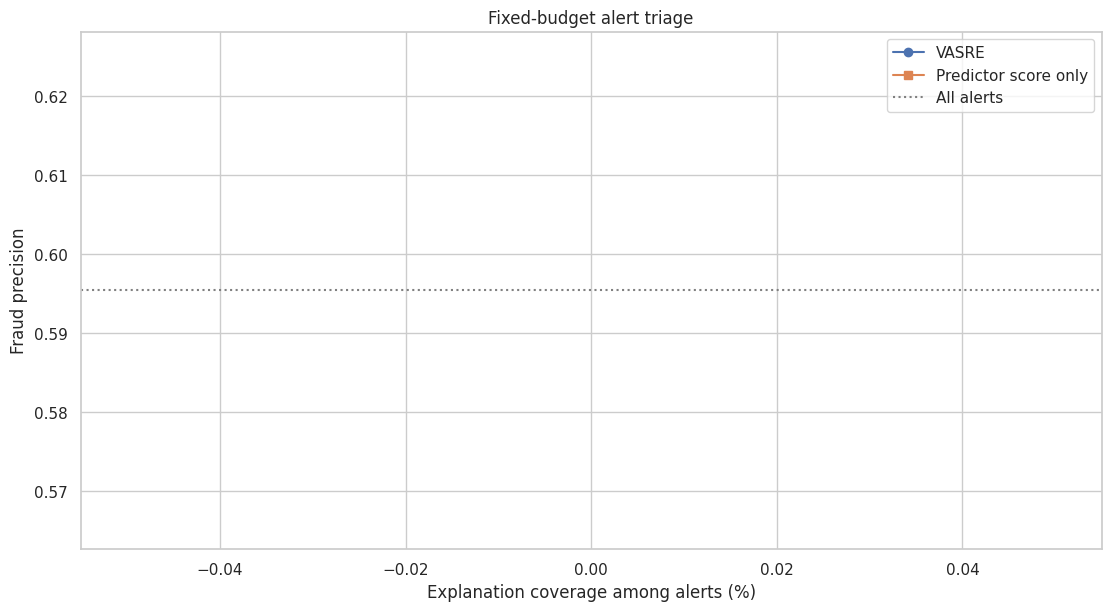

In [8]:
policies = pd.DataFrame(read_json("locked_policies.json"))
candidates = pd.read_csv(OUTPUT_DIR / "policy_candidates_validation.csv")
coverage = pd.read_csv(OUTPUT_DIR / "coverage_results.csv")
display(policies)
display(coverage)

plot_frame = coverage.copy()
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
ax.plot(plot_frame["coverage_budget"] * 100, plot_frame["selected_alert_precision"], marker="o", label="VASRE")
ax.plot(plot_frame["coverage_budget"] * 100, plot_frame["score_only_precision"], marker="s", label="Predictor score only")
ax.axhline(plot_frame["all_alert_precision"].iloc[0], color="grey", linestyle=":", label="All alerts")
ax.set(xlabel="Explanation coverage among alerts (%)", ylabel="Fraud precision", title="Fixed-budget alert triage")
ax.legend(loc="best")
plt.show()

## 8. Matched-risk, residual evidence and paired uncertainty

,coverage_budget,requested_selected_rows,matched_pairs,unmatched_rows,match_rate,mean_absolute_risk_gap,selected_precision,matched_control_precision,matched_precision_difference,matched_ci_low,matched_ci_high,probability_positive_difference
0,0.05,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.10,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.25,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.50,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,coverage_budget,risk_bin,rows,tp_count,fp_count,risk_min,risk_max,tp_evidence_mean,fp_evidence_mean,tp_fp_evidence_gap,comparison_weight
0,0.05,0,43,1,42,0.011895,0.017699,0.0,0.0,0.0,1
1,0.05,1,13,0,13,0.017988,0.025704,NaN,0.0,NaN,0
2,0.05,2,53,4,49,0.026753,0.073407,0.0,0.0,0.0,4
3,0.05,3,48,3,45,0.075074,0.421340,0.0,0.0,0.0,3
4,0.05,4,16,2,14,0.438685,0.608974,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...
75,0.50,15,25,25,0,0.999992,0.999994,0.0,NaN,NaN,0
76,0.50,16,14,14,0,0.999994,0.999995,0.0,NaN,NaN,0
77,0.50,17,20,20,0,0.999995,0.999996,0.0,NaN,NaN,0
78,0.50,18,9,9,0,0.999996,0.999997,0.0,NaN,NaN,0


,coverage,coverage_budget,outcome,preliminary_outcome,positive_confirmation_required,positive_incremental_evidence_confirmed,saturation_confirmation_required,saturation_confirmed,saturation_headroom_threshold,saturation_precision_margin,saturation_evidence_margin,minimum_positive_stability_fraction,minimum_saturation_alert_positives,minimum_saturation_matched_pairs,minimum_saturation_bootstrap_replicates,core_equal_count_score_only_comparison,negative_control_count_fair,mandatory_shuffled_control_names,shuffled_control_primary_realized_count,shuffled_control_primary_selected_precision,shuffled_control_rows_complete,shuffled_control_counts_match_primary,shuffled_control_metrics_finite,shuffled_control_comparison_valid,shuffled_control_max_selected_precision,shuffled_control_max_delta_vs_score_only,shuffled_controls_below_locked_primary,shuffled_controls_no_material_gain,shuffled_control_blockers,validation_label_shuffle_row_count,validation_label_shuffle_selected_count,validation_label_shuffle_score_only_selected_count,validation_label_shuffle_selected_precision,validation_label_shuffle_delta_vs_score_only,validation_weight_shuffle_row_count,validation_weight_shuffle_selected_count,validation_weight_shuffle_score_only_selected_count,validation_weight_shuffle_selected_precision,validation_weight_shuffle_delta_vs_score_only,observed_difference,bootstrap_mean_difference,ci_low,ci_high,probability_vasre_better,valid_iterations,bootstrap_unit
0,0.05,0.05,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block
1,0.10,0.10,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block
2,0.25,0.25,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block
3,0.50,0.50,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block


,coverage_budget,outcome,preliminary_outcome,positive_confirmation_required,positive_incremental_evidence_confirmed,saturation_confirmation_required,saturation_confirmed,saturation_headroom_threshold,saturation_precision_margin,saturation_evidence_margin,minimum_positive_stability_fraction,minimum_saturation_alert_positives,minimum_saturation_matched_pairs,minimum_saturation_bootstrap_replicates,core_equal_count_score_only_comparison,negative_control_count_fair,mandatory_shuffled_control_names,shuffled_control_primary_realized_count,shuffled_control_primary_selected_precision,shuffled_control_rows_complete,shuffled_control_counts_match_primary,shuffled_control_metrics_finite,shuffled_control_comparison_valid,shuffled_control_max_selected_precision,shuffled_control_max_delta_vs_score_only,shuffled_controls_below_locked_primary,shuffled_controls_no_material_gain,shuffled_control_blockers,validation_label_shuffle_row_count,validation_label_shuffle_selected_count,validation_label_shuffle_score_only_selected_count,validation_label_shuffle_selected_precision,validation_label_shuffle_delta_vs_score_only,validation_weight_shuffle_row_count,validation_weight_shuffle_selected_count,validation_weight_shuffle_score_only_selected_count,validation_weight_shuffle_selected_precision,validation_weight_shuffle_delta_vs_score_only,alert_rows,comparable_bins,comparison_weight,risk_conditioned_tp_fp_gap
0,0.05,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,482,6,23,0.0
1,0.10,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,482,6,23,0.0
2,0.25,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,482,6,23,0.0
3,0.50,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,482,6,23,0.0


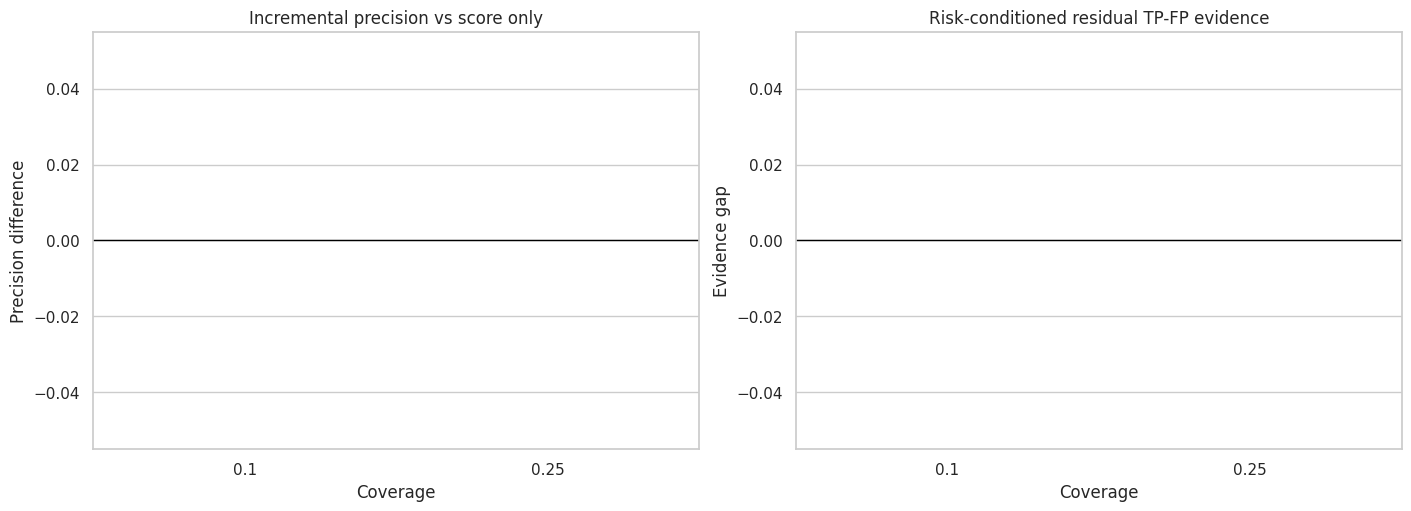

In [9]:
matched = pd.read_csv(OUTPUT_DIR / "matched_risk_results.csv")
residual = pd.read_csv(OUTPUT_DIR / "residual_evidence.csv")
bootstrap = pd.read_csv(OUTPUT_DIR / "paired_bootstrap.csv")
outcomes = pd.read_csv(OUTPUT_DIR / "stress_outcomes.csv")
display(matched)
display(residual)
display(bootstrap)
display(outcomes)

primary = coverage[coverage["coverage_budget"].round(2).isin([0.10, 0.25])]
if len(primary):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    sns.barplot(data=primary, x="coverage_budget", y="delta_vs_score_only", ax=axes[0], color="#4c72b0")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set(title="Incremental precision vs score only", xlabel="Coverage", ylabel="Precision difference")
    primary_outcomes = outcomes[outcomes["coverage_budget"].round(2).isin([0.10, 0.25])]
    sns.barplot(data=primary_outcomes, x="coverage_budget", y="risk_conditioned_tp_fp_gap", ax=axes[1], color="#55a868")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set(title="Risk-conditioned residual TP-FP evidence", xlabel="Coverage", ylabel="Evidence gap")
    plt.show()

## 9. Stability, negative controls, saturation and claim boundary

In [10]:
stability = pd.read_csv(OUTPUT_DIR / "validation_stability.csv")
rule_stability = pd.read_csv(OUTPUT_DIR / "rule_audit_stability.csv")
controls = pd.read_csv(OUTPUT_DIR / "negative_controls.csv")
summary = read_json("stress_summary.json")
manifest = read_json("stress_test_manifest.json")
lineage = read_json("stress_lineage.json")
display(stability)
display(rule_stability)
display(controls)
display(summary)
display({
    "claim_eligible": manifest["claim_eligible"],
    "claim_blockers": manifest["claim_blockers"],
    "stress_pipeline_fingerprint": manifest["stress_pipeline_fingerprint"],
    "lineage_outputs": len(lineage["outputs"]),
})

if QUICK_RUN or USE_TEST_FIXTURE:
    assert manifest["claim_eligible"] is False

,seed,dataset,predictor,coverage,method,abstain,reason,validation_alert_count,validation_selected_count,validation_all_alert_precision,validation_score_only_precision,validation_selected_precision,validation_delta_vs_score_only,validation_evidence_cutoff,minimum_score_only_delta,reference_method,reference_abstain,method_matches_reference,abstention_matches_reference,full_validation_selected_count,full_validation_requested_selected_count,full_validation_realized_coverage,full_validation_coverage_error,full_validation_selection_jaccard,full_validation_selected_precision,full_validation_score_only_selected_count,full_validation_score_only_precision,full_validation_score_only_requested_budget_precision,full_validation_equal_count_score_only_comparison,full_validation_delta_vs_score_only
0,42,amlnet_v1_0,xgboost:seed=42,0.05,NaN,True,no_method_beats_score_only_guardrail,123,0,0.804878,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,7,0.0,-0.05,1.0,NaN,0,NaN,1.0,True,NaN
1,42,amlnet_v1_0,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,123,0,0.804878,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,13,0.0,-0.10,1.0,NaN,0,NaN,1.0,True,NaN
2,42,amlnet_v1_0,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,123,0,0.804878,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,31,0.0,-0.25,1.0,NaN,0,NaN,1.0,True,NaN
3,42,amlnet_v1_0,xgboost:seed=42,0.50,NaN,True,no_method_beats_score_only_guardrail,123,0,0.804878,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,61,0.0,-0.50,1.0,NaN,0,NaN,1.0,True,NaN
4,123,amlnet_v1_0,xgboost:seed=42,0.05,NaN,True,no_method_beats_score_only_guardrail,121,0,0.793388,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,7,0.0,-0.05,1.0,NaN,0,NaN,1.0,True,NaN
5,123,amlnet_v1_0,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,121,0,0.793388,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,13,0.0,-0.10,1.0,NaN,0,NaN,1.0,True,NaN
6,123,amlnet_v1_0,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,121,0,0.793388,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,31,0.0,-0.25,1.0,NaN,0,NaN,1.0,True,NaN
7,123,amlnet_v1_0,xgboost:seed=42,0.50,NaN,True,no_method_beats_score_only_guardrail,121,0,0.793388,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,61,0.0,-0.50,1.0,NaN,0,NaN,1.0,True,NaN
8,2026,amlnet_v1_0,xgboost:seed=42,0.05,NaN,True,no_method_beats_score_only_guardrail,123,0,0.788618,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,7,0.0,-0.05,1.0,NaN,0,NaN,1.0,True,NaN
9,2026,amlnet_v1_0,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,123,0,0.788618,1.0,NaN,NaN,NaN,0.005,NaN,True,True,True,0,13,0.0,-0.10,1.0,NaN,0,NaN,1.0,True,NaN


,seed,selected_rule_count,reference_selected_rule_count,surviving_reference_rule_count,reference_rule_survival_rate,selected_rule_jaccard,selected_rules,mean_selected_audit_score,mean_selected_audit_alert_coverage,mean_selected_audit_alert_lift,audit_alert_sample_count,stability_blocker,validation_or_test_refit,test_data_used
0,42,1,1,1,1.0,1.0,"[""high_transaction_amount""]",0.280547,0.427586,1.169355,145,NaN,False,False
1,123,1,1,1,1.0,1.0,"[""high_transaction_amount""]",0.313091,0.372414,1.220539,145,NaN,False,False
2,2026,1,1,1,1.0,1.0,"[""high_transaction_amount""]",0.337579,0.413793,1.230303,145,NaN,False,False
3,1705,1,1,1,1.0,1.0,"[""high_transaction_amount""]",0.359065,0.372414,1.269360,145,NaN,False,False
4,2027,1,1,1,1.0,1.0,"[""high_transaction_amount""]",0.270870,0.379310,1.174380,145,NaN,False,False


,coverage_budget,control,alert_count,requested_selected_count,matched_realized_selected_count,selected_count,equal_count_with_locked_vasre,achieved_alert_coverage,selected_precision,uses_test_labels_for_ranking,policy_abstained
0,0.05,locked_vasre,482,25,0,0,True,0.0,NaN,False,True
1,0.05,predictor_score_only,482,25,0,0,True,0.0,NaN,False,True
2,0.05,row_permuted_evidence,482,25,0,0,True,0.0,NaN,False,True
3,0.05,random_evidence,482,25,0,0,True,0.0,NaN,False,True
4,0.10,locked_vasre,482,49,0,0,True,0.0,NaN,False,True
5,0.10,predictor_score_only,482,49,0,0,True,0.0,NaN,False,True
6,0.10,row_permuted_evidence,482,49,0,0,True,0.0,NaN,False,True
7,0.10,random_evidence,482,49,0,0,True,0.0,NaN,False,True
8,0.25,locked_vasre,482,121,0,0,True,0.0,NaN,False,True
9,0.25,predictor_score_only,482,121,0,0,True,0.0,NaN,False,True


{'dataset': 'amlnet_v1_0',
 'dataset_label': 'AMLNet v1.0',
 'reference_predictor': 'xgboost',
 'reference_backend': 'xgboost',
 'reference_seed': 42,
 'reference_test_pr_auc': 0.9481039536817348,
 'reference_test_roc_auc': 0.9978165331874668,
 'audited_rules': 7,
 'selected_rules': 1,
 'policy_abstentions': 4,
 'primary_outcomes': [{'coverage_budget': 0.1,
   'outcome': 'guardrail_abstention'},
  {'coverage_budget': 0.25, 'outcome': 'guardrail_abstention'}],
 'outcome_decision_thresholds': {'saturation_headroom': 0.05,
  'saturation_precision_margin': 0.02,
  'saturation_evidence_margin': 0.05,
  'minimum_positive_stability_fraction': 0.8,
  'minimum_saturation_alert_positives': 20,
  'minimum_saturation_matched_pairs': 20,
  'minimum_saturation_bootstrap_replicates': 200},
 'selection_signature_sha256': '06642573b79b86d22041088d66db3859c27273378c1e10088f447b6136d87fe7',
 'ablation_selection_signature_sha256': '645667f120d6d056c6e1f73edf364fdbcc19ea2e2380e5bab60ac5a325174502',
 'predi

{'claim_eligible': True,
 'claim_blockers': [],
 'stress_pipeline_fingerprint': '3f8d4a53966b41d3ed6a283e291a835302c45f9318000f2f096fcdf2bc4686fd',
 'lineage_outputs': 58}

## 10. Diễn giải kết quả đúng phạm vi

- Kết quả dương chỉ được xác nhận khi paired bootstrap, matched-risk, residual evidence,
  validation stability và negative controls cùng hỗ trợ; label-shuffle và weight-shuffle
  validation controls là hai cổng bắt buộc. Một CI dương riêng lẻ là chưa đủ.
- Domain Tier A only, exact counterfactual-only và all Tier B tự deduplicate/select/weight từ
  complete pre-dedup audit pool; chúng không chỉ lọc các rule đã thắng trong primary A/B pool.
- Kết quả âm hoặc abstention cho thấy rule evidence chưa tạo incremental value trong protocol này.
- Rule audit, TP-FP metrics, weighting và deduplication chỉ dùng frozen-predictor alerts; TN/FN ngoài alert region chỉ xuất hiện trong population diagnostics.
- Counterfactual-only là đúng tập rule có source `train_model_counterfactual`; `train_derived_tier_b_only` rộng hơn và được báo riêng.
- Tier C CART và signed native-attribution top-k là baseline chẩn đoán, không được nhập vào primary A/B policy.
- Contrastive meta-scorer dùng audited rule truth cùng frozen calibrated risk và chỉ fit trên TP/FP alerts của `rule_audit`; fallback thiếu mẫu/lớp được báo rõ và không được âm thầm fit trên test.
- Guarded ensemble là trung bình của các component đã khóa trong YAML, sau đó vẫn phải qua score-only và resampling-stability guardrails trên `policy_select`.
- Saturation chỉ được xác nhận cho AMLNet full/checksummed run khi đủ positive, matched pairs,
  bootstrap replicates và toàn bộ lineage/attribution guardrails; TransXion không mang nhãn này.
- Matched-risk và residual TP-FP làm giảm một số confounding theo risk score nhưng không chứng minh nhân quả.
- Stress test không chứng minh production generalization hoặc hiệu quả với chuyên viên AML thực tế.

Hãy lưu một Kaggle version hoàn tất để bảo toàn toàn bộ files trong `OUTPUT_DIR`. Notebook 11
chỉ tổng hợp version outputs này và không được chọn lại model, rule hoặc policy.